In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
salary=pd.read_csv("Salary Data.csv")

In [185]:
salary

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
370,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
371,43.0,Male,Master's,Director of Operations,19.0,170000.0
372,29.0,Female,Bachelor's,Junior Project Manager,2.0,40000.0
373,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,90000.0


In [186]:
salary.info()

<class 'pandas.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    str    
 2   Education Level      373 non-null    str    
 3   Job Title            373 non-null    str    
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), str(3)
memory usage: 30.8 KB


In [187]:
salary.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,373.0,NaN,NaN,NaN,37.431635,7.069073,23.0,31.0,36.0,44.0,53.0
Gender,373,2,Male,194,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education Level,373,3,Bachelor's,224,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job Title,373,174,Director of Marketing,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Years of Experience,373.0,NaN,NaN,NaN,10.030831,6.557007,0.0,4.0,9.0,15.0,25.0
Salary,373.0,NaN,NaN,NaN,100577.345845,48240.013482,350.0,55000.0,95000.0,140000.0,250000.0


In [188]:
salary.isna().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

In [189]:
salary.dropna(inplace=True)

In [190]:
salary.duplicated().sum()

np.int64(49)

In [191]:
salary=salary.drop_duplicates()

In [192]:
salary.info()

<class 'pandas.DataFrame'>
Index: 324 entries, 0 to 371
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  324 non-null    float64
 1   Gender               324 non-null    str    
 2   Education Level      324 non-null    str    
 3   Job Title            324 non-null    str    
 4   Years of Experience  324 non-null    float64
 5   Salary               324 non-null    float64
dtypes: float64(3), str(3)
memory usage: 29.0 KB


Deep dive into each column:

AGE:

In [193]:
print(salary['Age'].median())
salary['Age'].describe()

36.5


count    324.000000
mean      37.382716
std        7.185844
min       23.000000
25%       31.000000
50%       36.500000
75%       44.000000
max       53.000000
Name: Age, dtype: float64

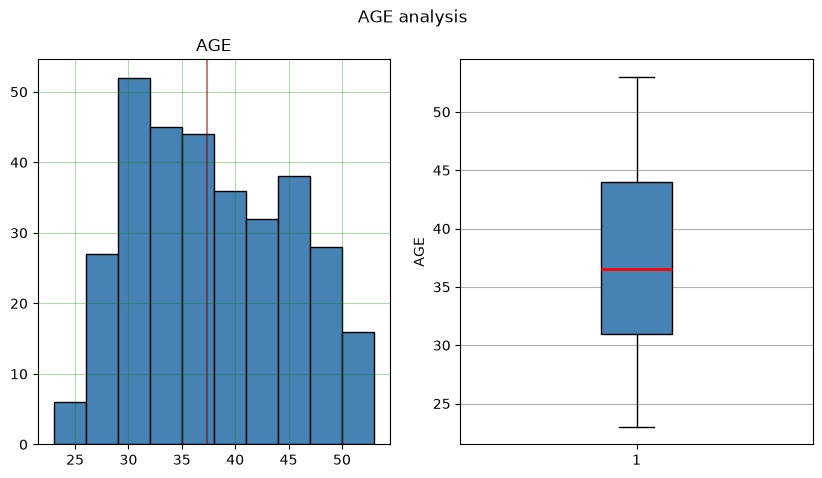

In [194]:
fig,ax = plt.subplots(1,2,figsize=(10,5))
ax[0].hist(salary['Age'],bins='auto',color="steelblue", edgecolor="Black")
ax[0].grid(axis="both", alpha=.3,color='Green')
ax[0].axvline(salary["Age"].mean(),color='darkred',alpha=.5)
ax[0].set_title("AGE")


ax[1].boxplot(salary['Age'],patch_artist=True, widths=0.2,
                boxprops=dict(facecolor="steelblue", edgecolor="black"),
                medianprops=dict(color="red", linewidth=2),
                whiskerprops=dict(color="black"),
                capprops=dict(color="black"),
            )
ax[1].grid(axis='y')
ax[1].set_ylabel('AGE')

fig.suptitle("AGE analysis")
plt.show()

Gender Colulmn

In [195]:
(salary['Gender'].value_counts(normalize=True)*100).apply(lambda x: f"{x:0.2f}%")

Gender
Male      52.47%
Female    47.53%
Name: proportion, dtype: str

Text(0.5, 1.0, 'Gender')

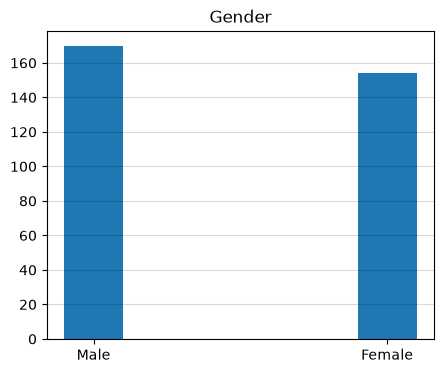

In [196]:
fig,ax=plt.subplots(figsize=(5,4))
ax.bar(salary['Gender'].value_counts().index,height=salary['Gender'].value_counts(),width=.2)
ax.grid(axis='y',color='black',alpha=.15)
ax.set_title("Gender")


Education Level

In [197]:
salary['Education Level'].value_counts(normalize=True)

Education Level
Bachelor's    0.589506
Master's      0.280864
PhD           0.129630
Name: proportion, dtype: float64

Text(0.5, 1.0, 'Education Level')

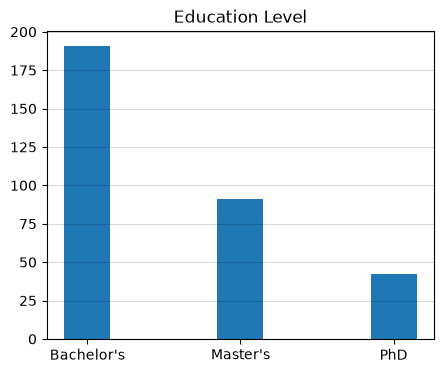

In [198]:
fig,ax=plt.subplots(figsize=(5,4))
ax.bar(salary['Education Level'].value_counts().index,height=salary['Education Level'].value_counts(),width=.3)
ax.grid(axis='y',color='black',alpha=.15)
ax.set_title("Education Level")

Job Title

In [199]:
salary['Job Title'].value_counts()

Job Title
Director of Operations           9
Director of Marketing            8
Senior Marketing Manager         8
Senior Project Manager           7
Senior Data Scientist            6
                                ..
Junior Research Scientist        1
Senior HR Specialist             1
Junior Operations Coordinator    1
Director of HR                   1
Junior Financial Advisor         1
Name: count, Length: 174, dtype: int64

In [200]:
salary['Job Title'].nunique()

174

In [201]:
salary.drop(['Job Title'],axis=1,inplace=True)

In [202]:
salary

,Age,Gender,Education Level,Years of Experience,Salary
0,32.0,Male,Bachelor's,5.0,90000.0
1,28.0,Female,Master's,3.0,65000.0
2,45.0,Male,PhD,15.0,150000.0
3,36.0,Female,Bachelor's,7.0,60000.0
4,52.0,Male,Master's,20.0,200000.0
...,...,...,...,...,...
348,28.0,Female,Bachelor's,1.0,35000.0
349,36.0,Male,Bachelor's,8.0,110000.0
350,44.0,Female,PhD,16.0,160000.0
351,31.0,Male,Bachelor's,3.0,55000.0


Years of Experience

In [203]:
print(salary['Years of Experience'].median())
salary['Years of Experience'].describe()

9.0


count    324.000000
mean      10.058642
std        6.650470
min        0.000000
25%        4.000000
50%        9.000000
75%       16.000000
max       25.000000
Name: Years of Experience, dtype: float64

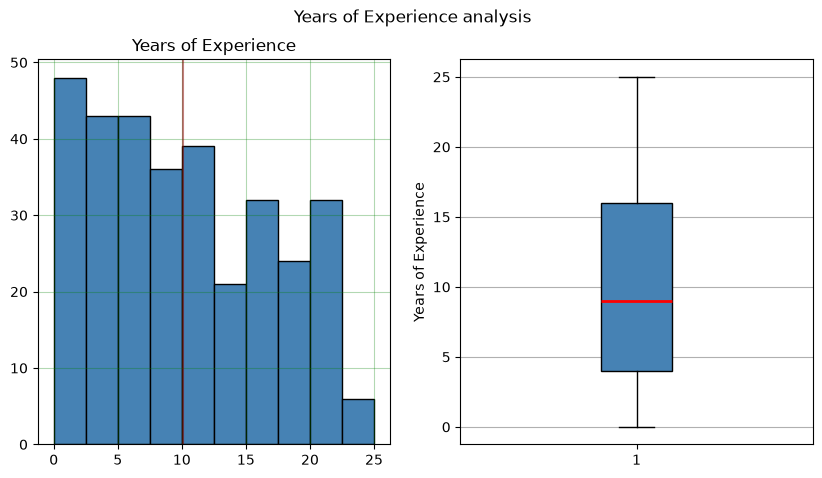

In [204]:
fig,ax = plt.subplots(1,2,figsize=(10,5))
ax[0].hist(salary['Years of Experience'],bins='auto',color="steelblue", edgecolor="Black")
ax[0].grid(axis="both", alpha=.3,color='Green')
ax[0].axvline(salary["Years of Experience"].mean(),color='darkred',alpha=.5)
ax[0].set_title("Years of Experience")


ax[1].boxplot(salary['Years of Experience'],patch_artist=True, widths=0.2,
                boxprops=dict(facecolor="steelblue", edgecolor="black"),
                medianprops=dict(color="red", linewidth=2),
                whiskerprops=dict(color="black"),
                capprops=dict(color="black"),
            )
ax[1].grid(axis='y')
ax[1].set_ylabel('Years of Experience')

fig.suptitle("Years of Experience analysis")
plt.show()

Salary Analysis

In [205]:
print(salary['Salary'].median())
salary['Salary'].describe()

95000.0


count       324.000000
mean      99985.648148
std       48652.271440
min         350.000000
25%       55000.000000
50%       95000.000000
75%      140000.000000
max      250000.000000
Name: Salary, dtype: float64

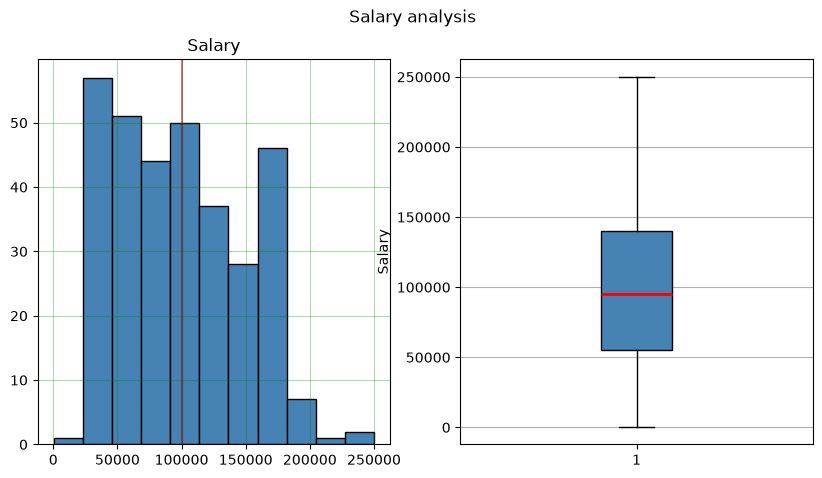

In [206]:
fig,ax = plt.subplots(1,2,figsize=(10,5))
ax[0].hist(salary['Salary'],bins='auto',color="steelblue", edgecolor="Black")
ax[0].grid(axis="both", alpha=.3,color='Green')
ax[0].axvline(salary["Salary"].mean(),color='darkred',alpha=.5)
ax[0].set_title("Salary")


ax[1].boxplot(salary['Salary'],patch_artist=True, widths=0.2,
                boxprops=dict(facecolor="steelblue", edgecolor="black"),
                medianprops=dict(color="red", linewidth=2),
                whiskerprops=dict(color="black"),
                capprops=dict(color="black"),
            )
ax[1].grid(axis='y')
ax[1].set_ylabel('Salary')

fig.suptitle("Salary analysis")
plt.show()

In [207]:
#min looks suspicious lets check
salary['Salary'].sort_values() #350 can be a wrong data entry therefore it is better to drop it

259       350.0
82      30000.0
18      35000.0
49      35000.0
114     35000.0
         ...   
4      200000.0
53     200000.0
105    220000.0
83     250000.0
30     250000.0
Name: Salary, Length: 324, dtype: float64

In [208]:
salary=salary[salary['Salary']>350]

Text(0.5, 1.0, 'Salary')

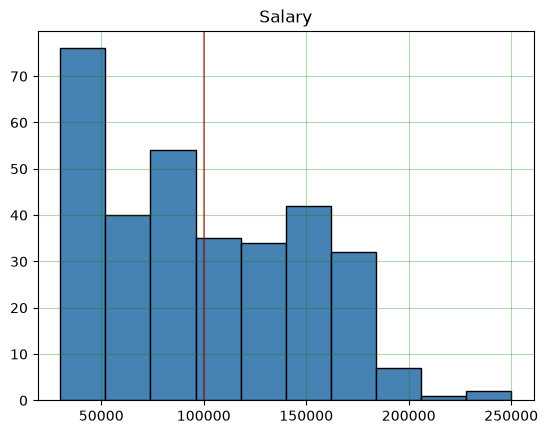

In [209]:
fig,ax = plt.subplots()
ax.hist(salary['Salary'],bins='auto',color="steelblue", edgecolor="Black")
ax.grid(axis="both", alpha=.3,color='Green')
ax.axvline(salary["Salary"].mean(),color='darkred',alpha=.5)
ax.set_title("Salary")

In [210]:
print(salary['Salary'].median())
salary['Salary'].describe()

95000.0


count       323.000000
mean     100294.117647
std       48409.390895
min       30000.000000
25%       55000.000000
50%       95000.000000
75%      140000.000000
max      250000.000000
Name: Salary, dtype: float64

Encoding

In [211]:
#one hot encoding Gender

salary=pd.get_dummies(data=salary,columns=['Gender','Education Level'],dtype=bool,drop_first=True)

In [212]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [213]:
X= salary.drop(columns=['Salary'])
y= salary['Salary']

In [214]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2)

In [215]:
scaler = StandardScaler()
X_train[['Age','Years of Experience']] = scaler.fit_transform(X_train[['Age','Years of Experience']])   # fit AND transform on train
X_test[['Age','Years of Experience']] = scaler.transform(X_test[['Age','Years of Experience']])

In [216]:
X_train

,Age,Years of Experience,Gender_Male,Education Level_Master's,Education Level_PhD
136,1.244229,1.372767,True,True,False
56,-1.416858,-1.178486,False,True,False
342,-0.856629,-1.028412,False,False,False
76,1.804458,1.822989,False,False,False
280,-0.856629,-1.028412,True,False,False
...,...,...,...,...,...
326,0.824058,0.772473,False,False,True
302,0.123771,-0.127970,False,False,False
234,0.684000,0.472325,False,False,True
271,-0.716572,-0.878338,False,False,False


In [217]:
model=LinearRegression()
model.fit(X_train,y_train)
model.coef_

array([20931.52454379, 18381.61986267,  9004.91152215, 17069.01059279,
       24465.39912866])

In [218]:
y_test_predicted=model.predict(X_test)

In [219]:
scaler

StandardScaler()

In [220]:
scaler.transform([[50,16]])

d:\Projects\FEBS_Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[1.80445815, 0.92254624]])

In [221]:
inp_dict={
    "Age": 35,
    "Years of Experience": 5,
    "Gender_Male": 1,
    "Education Level_Master's": 0,
    "Education Level_PhD": 1
}

In [241]:
df = pd.DataFrame([inp_dict])[X_test.columns]

In [242]:
df[['Age','Years of Experience']] = scaler.transform(df[['Age','Years of Experience']])

In [243]:
df

,Age,Years of Experience,Gender_Male,Education Level_Master's,Education Level_PhD
0,-0.2964,-0.728265,1,0,1


In [225]:
predict = model.predict(df)
predict

array([118439.65121299])

In [ ]:
def get_user_input():
    age = int(input("Enter your age: "))
    year_of_exp = int(input("Year of experience: "))
    gender = str(input("Enter your Gender (male/female): ")).strip().lower()
    edu_lvl = str(input("Enter your level of education (bachelor's/master's/phd): ")).strip().lower()
    
    return age,year_of_exp,gender,edu_lvl

In [ ]:
age,year_of_exp,gender,edu_lvl = get_user_input ()
inp_dict_={
    "Age": age,
    "Years of Experience": year_of_exp,
    "Gender_Male": int(gender == "male"),
    "Education Level_Master's": int(edu_lvl == "master's"),
    "Education Level_PhD": int(edu_lvl == "phd")
}

In [237]:
inp_dict_

{'Age': 40,
 'Years of Experience': 10,
 'Gender_Male': 1,
 "Education Level_Master's": 0,
 'Education Level_PhD': 0}

In [238]:
df = pd.DataFrame([inp_dict_])[X_test.columns]
df

,Age,Years of Experience,Gender_Male,Education Level_Master's,Education Level_PhD
0,40,10,1,0,0


In [239]:
df[['Age','Years of Experience']] = scaler.transform(df[['Age','Years of Experience']])

In [240]:
predict = model.predict(df)
predict

array([103781.59538824])

In [246]:
list(X_train.columns)

['Age',
 'Years of Experience',
 'Gender_Male',
 "Education Level_Master's",
 'Education Level_PhD']